<a href="https://colab.research.google.com/github/ByronUEES/Comportamiento-Personalizado/blob/main/Segmentaci%C3%B3n_de_Usuarios_con_Aprendizaje_No_Supervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import os

base_path = "/content/unsupervised_user_segmentation"

folders = [
    "data",
    "notebooks",
    "src",
    "outputs/figures",
    "outputs/tables"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("✅ Estructura creada correctamente")


✅ Estructura creada correctamente


In [14]:
from google.colab import files
uploaded = files.upload()


Saving user_behavior_dataset.csv to user_behavior_dataset.csv


In [15]:
import shutil

shutil.move(
    "user_behavior_dataset.csv",  # nombre del archivo subido
    "/content/unsupervised_user_segmentation/data/user_behavior_dataset.csv"
)

print("✅ Dataset movido al proyecto")


✅ Dataset movido al proyecto


In [12]:
!pip install pandas numpy scikit-learn matplotlib seaborn


Silhouette KMeans: 0.16699766610575784


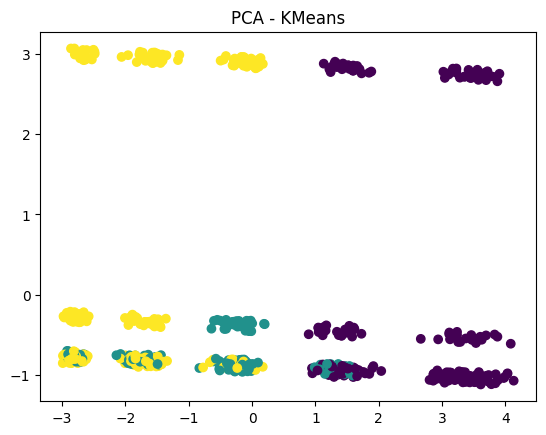

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Cargar datos
df = pd.read_csv("/content/unsupervised_user_segmentation/data/user_behavior_dataset.csv")

# Eliminar columnas irrelevantes
df = df.drop(columns=["User ID", "User Behavior Class"], errors="ignore")

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Escalar
scaler = StandardScaler()
X = scaler.fit_transform(df)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
k_labels = kmeans.fit_predict(X)

print("Silhouette KMeans:", silhouette_score(X, k_labels))

# DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
d_labels = dbscan.fit_predict(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=k_labels)
plt.title("PCA - KMeans")
plt.show()
